In [1]:
from load_data import load_data

train_path = "train.csv"
val_path = "validation.csv"

train_data = load_data(train_path)
val_data = load_data(val_path)

torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor(4)


[ WARN:0@8.100] global loadsave.cpp:1089 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor(5)


In [6]:
import torch.nn as nn
import torch

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        b, c, h, w = x.size()

        # Squeeze
        y = x.mean(dim=(2, 3))  # Global Avg Pool

        # Excitation
        y = torch.relu(self.fc1(y))
        y = torch.sigmoid(self.fc2(y))

        y = y.view(b, c, 1, 1)

        # Scale
        return x * y

In [3]:
import torchvision.models as models

class ResNet18_SE(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.backbone = models.resnet18(pretrained=False)

        # load pretrained weights
        state_dict = torch.load("resnet18-f37072fd.pth")
        self.backbone.load_state_dict(state_dict)

        # SE blocks
        self.se1 = SEBlock(64)
        self.se2 = SEBlock(128)
        self.se3 = SEBlock(256)
        self.se4 = SEBlock(512)

        # replace fc
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)

        x = self.backbone.layer1(x)
        x = self.se1(x)

        x = self.backbone.layer2(x)
        x = self.se2(x)

        x = self.backbone.layer3(x)
        x = self.se3(x)

        x = self.backbone.layer4(x)
        x = self.se4(x)

        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.backbone.fc(x)

        return x

In [4]:
import urllib.request
import ssl
import certifi

url = "https://download.pytorch.org/models/resnet18-f37072fd.pth"
ctx = ssl.create_default_context(cafile=certifi.where())

req = urllib.request.Request(
    url,
    headers={"User-Agent": "Mozilla/5.0"}  # pretend to be a browser
)

with urllib.request.urlopen(req, context=ctx) as response:
    data = response.read()
    with open("resnet18-f37072fd.pth", "wb") as f:
        f.write(data)

print("Downloaded weights!")

Downloaded weights!


In [5]:
import torch
import torch.optim as optim
import torch.nn as nn
import params

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = ResNet18_SE(num_classes=10)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=params.lr)

/Users/adit/Documents/Acads/Vision/Assignments/A3/vevn/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/adit/Documents/Acads/Vision/Assignments/A3/vevn/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
outfile = open("results.txt", 'a')
outfile.write("----------------------------\n")
outfile.write("Training for task 1.2\n")
outfile.write("---------------------\n")

In [ ]:
import time
from params import num_epochs
import numpy as np
from sklearn.metrics import roc_auc_score

best_auc = 0
best_model_state = None
losses = []
auc_vals = []

for epoch in range(num_epochs):
  start = time.time()
  model.train()
  train_loss = 0

  outfile.write(f"Running epoch: {epoch+1}")

  for images, labels in train_data:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    train_loss += loss.item()
  
  train_loss /= len(train_data)

  model.eval()
  all_labels = []
  all_probs = []

  outfile.write(f"  Evaluations for the epoch")

  with torch.no_grad():
    for images, labels in val_data:
      images = images.to(device)
      outputs = model(images)
      probs = torch.softmax(outputs, dim=1)

      all_probs.append(probs.cpu().numpy())
      all_labels.append(labels.numpy())

  all_probs = np.concatenate(all_probs)
  all_labels = np.concatenate(all_labels)

  from sklearn.preprocessing import label_binarize
  y_true = label_binarize(all_labels, classes=list(range(10)))

  auc = roc_auc_score(y_true, all_probs, average='macro', multi_class='ovr')
  losses.append(train_loss)
  auc_vals.append(auc)

  outfile.write(f"Epoch {epoch+1} done, Val AUC: {auc:.4f}")
  outfile.write(f"Time taken: {time.time()-start:.2f}s")

  if auc > best_auc:
    best_auc = auc
    best_model_state = model.state_dict()

Running epoch: 1
  Evaluations for the epoch
Epoch 1 done, Val AUC: 0.9994
Time taken: 130.29s
Running epoch: 2
  Evaluations for the epoch
Epoch 2 done, Val AUC: 0.9995
Time taken: 123.71s
Running epoch: 3
  Evaluations for the epoch
Epoch 3 done, Val AUC: 0.9993
Time taken: 123.01s
Running epoch: 4
  Evaluations for the epoch
Epoch 4 done, Val AUC: 0.9996
Time taken: 124.27s
Running epoch: 5
  Evaluations for the epoch
Epoch 5 done, Val AUC: 0.9992
Time taken: 123.85s
Running epoch: 6
  Evaluations for the epoch
Epoch 6 done, Val AUC: 0.9993
Time taken: 124.27s
Running epoch: 7
  Evaluations for the epoch
Epoch 7 done, Val AUC: 0.9993
Time taken: 124.11s
Running epoch: 8
  Evaluations for the epoch
Epoch 8 done, Val AUC: 0.9996
Time taken: 124.18s
Running epoch: 9
  Evaluations for the epoch
Epoch 9 done, Val AUC: 0.9994
Time taken: 123.16s
Running epoch: 10
  Evaluations for the epoch
Epoch 10 done, Val AUC: 0.9995
Time taken: 123.20s


In [ ]:
outfile.close()

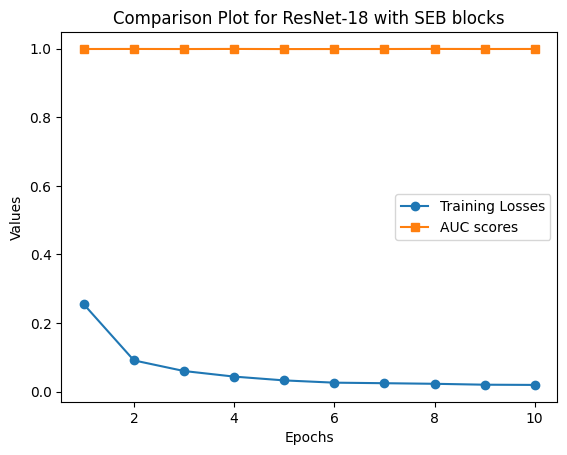

In [8]:
import matplotlib.pyplot as plt

x = list(range(1, 11))

plt.plot(x, losses, marker='o', label='Training Losses')
plt.plot(x, auc_vals, marker='s', label='AUC scores')

plt.xlabel("Epochs")
plt.ylabel("Values")
plt.title("Comparison Plot for ResNet-18 with SEB blocks")
plt.legend()

plt.show()

In [9]:
torch.save(best_model_state, "best_model12.pth")

In [ ]:
with open("results.txt", "a") as f:
    f.write("\n------------------------------\n")
    f.write("Train results for 1.2\n")
    f.write("------------------------------\n")
    f.write("Losses:\n")
    for ls in losses:
        f.write(f"{ls}\n")
    f.write("AUC values:\n")
    for auc in auc_vals:
        f.write(f"{auc}\n")